In [1]:
import os
import numpy as np
import pandas as pd

from dekef.base_density import *
from dekef.kernel_function import *
from dekef.data_median_dist import *
from dekef.negloglik_params import *

from dekef.negloglik_grid_points import *
from dekef.scorematching_penalized_grid_points import *

from dekef.plot_density_1d import *

from IPython.display import Markdown as md

from datetime import datetime as dt

import warnings
warnings.filterwarnings('ignore')
np.random.seed(1989)

In [2]:
df = np.load('../data/geyser.npy').astype(np.float64)
waiting = df[:, 0]# .reshape(-1, 1)
waiting = waiting[waiting != 108.0]
waiting[waiting <= 70.] = waiting[waiting <= 70.] - 20
waiting[waiting > 70.] = waiting[waiting > 70.] + 20
waiting = np.append(waiting, 70.)

# waiting = np.append(waiting, contam_pt)

bw = 5.
kernel_type = 'gaussian_poly2'

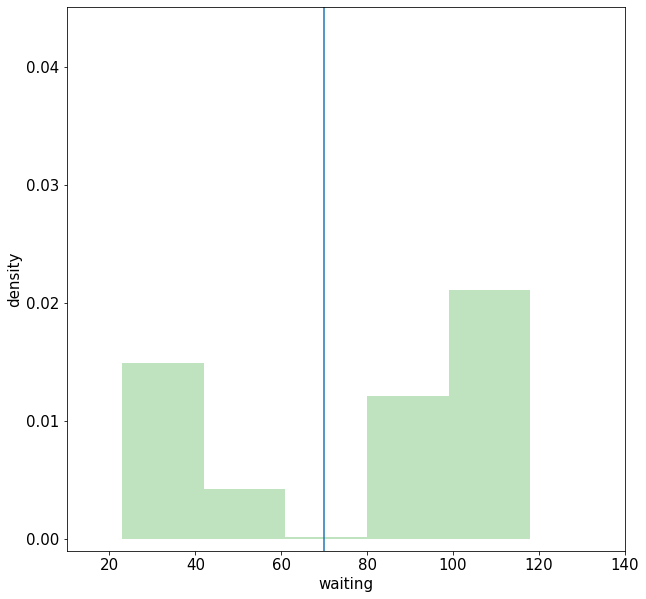

In [3]:
# set plot parameters
font_size = 15
xlimit = (10., 140.)
plot_pts_cnt = 3000
ylimit = (-0.001, 0.0451)

# plot the histogram of waiting variable 
ax = pd.Series(waiting.flatten()).hist(grid = False, figsize = (10, 10), 
                                       bins = 'fd', density = True, color = 'tab:green', alpha = 0.3)
ax.set_xlim(xlimit)
ax.set_ylim(ylimit)
# ax.set_title('Histogram of Waiting Variable', fontsize = font_size)
ax.set_xlabel('waiting', fontsize = font_size)
ax.set_ylabel('density', fontsize = font_size)
ax.tick_params(axis = 'both', labelsize = font_size)
ax.axvline(70.)

# plt.savefig(f'../plots/histogram.pdf', bbox_inches = 'tight')

In [4]:
np.sort(waiting)

array([ 23.,  25.,  27.,  27.,  28.,  28.,  28.,  28.,  28.,  29.,  29.,
        29.,  29.,  29.,  29.,  29.,  30.,  30.,  30.,  30.,  30.,  30.,
        30.,  30.,  30.,  30.,  30.,  30.,  31.,  31.,  31.,  31.,  31.,
        32.,  32.,  32.,  32.,  32.,  33.,  33.,  33.,  33.,  33.,  33.,
        33.,  34.,  34.,  34.,  34.,  34.,  34.,  34.,  34.,  34.,  35.,
        35.,  35.,  36.,  36.,  37.,  37.,  37.,  37.,  37.,  37.,  37.,
        37.,  37.,  38.,  38.,  38.,  38.,  38.,  39.,  39.,  39.,  40.,
        40.,  40.,  40.,  40.,  40.,  41.,  41.,  41.,  42.,  42.,  42.,
        42.,  42.,  43.,  44.,  45.,  45.,  45.,  45.,  45.,  45.,  45.,
        46.,  46.,  48.,  48.,  48.,  49.,  49.,  49.,  49.,  50.,  70.,
        91.,  91.,  91.,  91.,  91.,  92.,  92.,  92.,  92.,  92.,  92.,
        93.,  93.,  93.,  93.,  93.,  93.,  94.,  94.,  94.,  94.,  94.,
        94.,  94.,  94.,  95.,  95.,  95.,  95.,  95.,  95.,  95.,  95.,
        95.,  96.,  96.,  96.,  96.,  96.,  96.,  9

In [5]:
len(waiting)

299

In [6]:
base_density = BasedenUniform(waiting, [[0., 100000.]]) # BasedenGamma(waiting, 26., 3.)
# base_density.a, base_density.scale

In [7]:
grid_points = np.arange(1., 181., 1).reshape(-1, 1)
sm_pen = ScoreMatchingPenalizedGridPoints(
    data = waiting, 
    grid_points = grid_points,
    base_density = base_density,
    kernel_type = 'gaussian_poly2', 
    kernel_r1 = 1.0, 
    kernel_r2 = 0.0, 
    kernel_c = 0.0, 
    kernel_bw = bw)

In [8]:
plot_params = plot_density_1d_params(xlimit, ylimit, plot_pts_cnt=plot_pts_cnt)

new_data = np.linspace(xlimit[0], xlimit[1], plot_pts_cnt)

# sm_folder = (f'../data/data=geyser-waiting-splitted-PenSM-FinKEF-bw={bw}-kernel={kernel_type}-' + 
#              f'plotdomain={xlimit}-plotcnts={plot_pts_cnt}-baseden=Gamma-{base_density.a}-{base_density.scale}-' + 
#              f'grid_points=1-181-1')

# if not os.path.isdir(sm_folder):
#     os.mkdir(sm_folder)

# file_name_newdata = f'/new_data.npy'
# np.save(sm_folder + file_name_newdata, new_data)

# file_name_grid_points = f'/grid_points.npy'
# np.save(sm_folder + file_name_grid_points, grid_points)

**************************************************
log penalty = -12.0


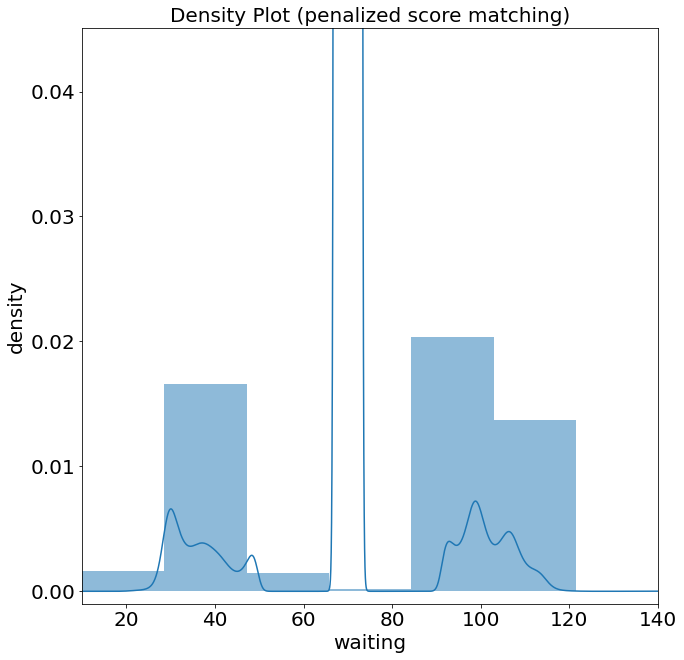

**************************************************
log penalty = -11.5


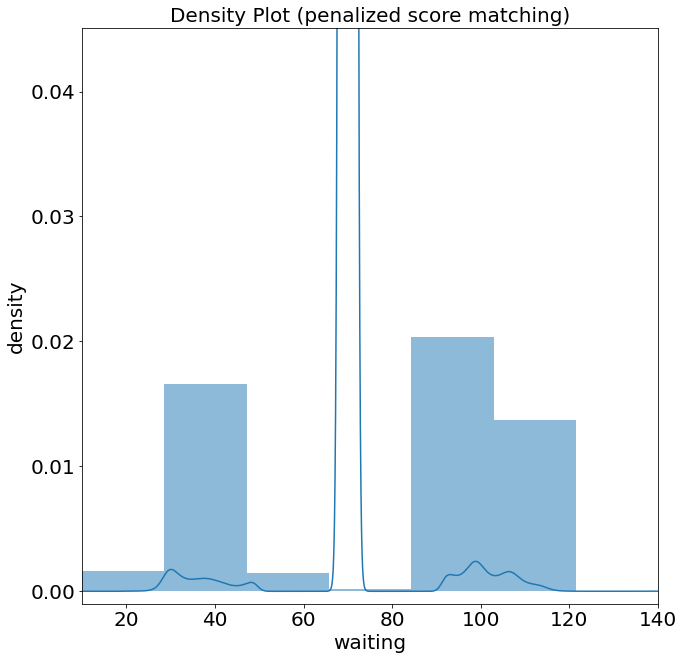

**************************************************
log penalty = -11.0


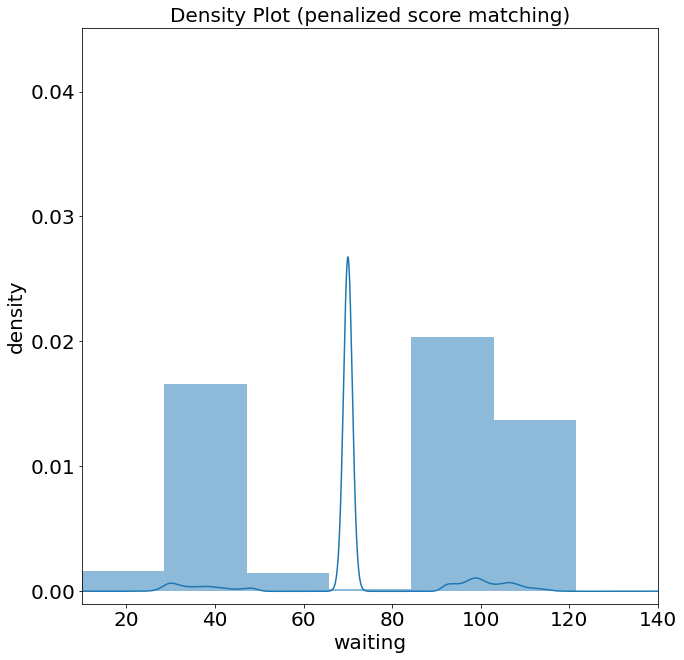

**************************************************
log penalty = -10.5


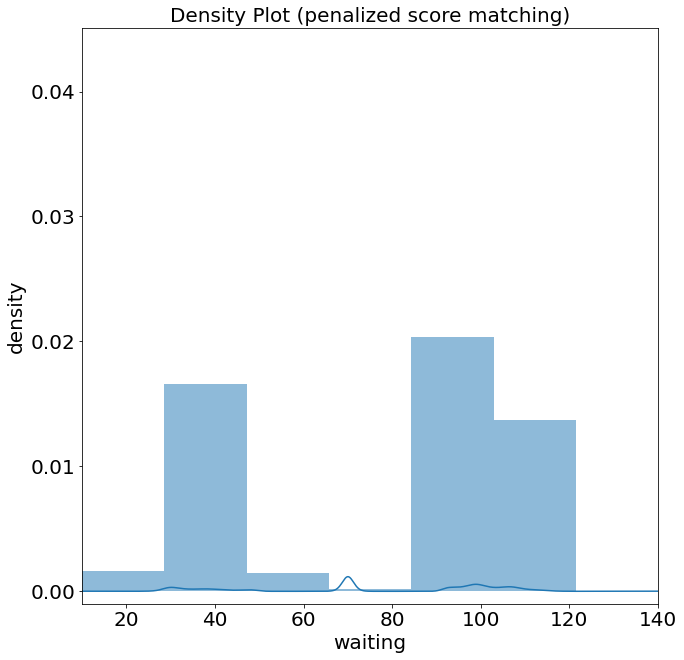

**************************************************
log penalty = -10.0


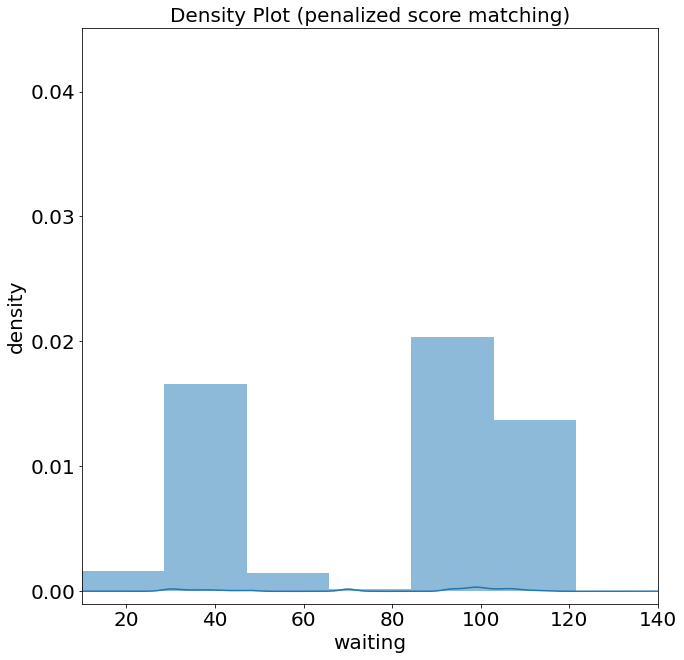

**************************************************
log penalty = -9.5


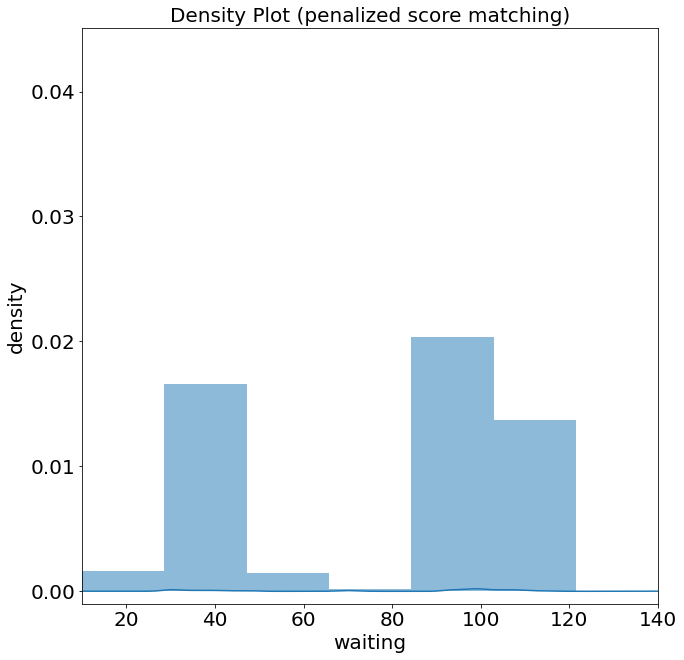

**************************************************
log penalty = -9.0


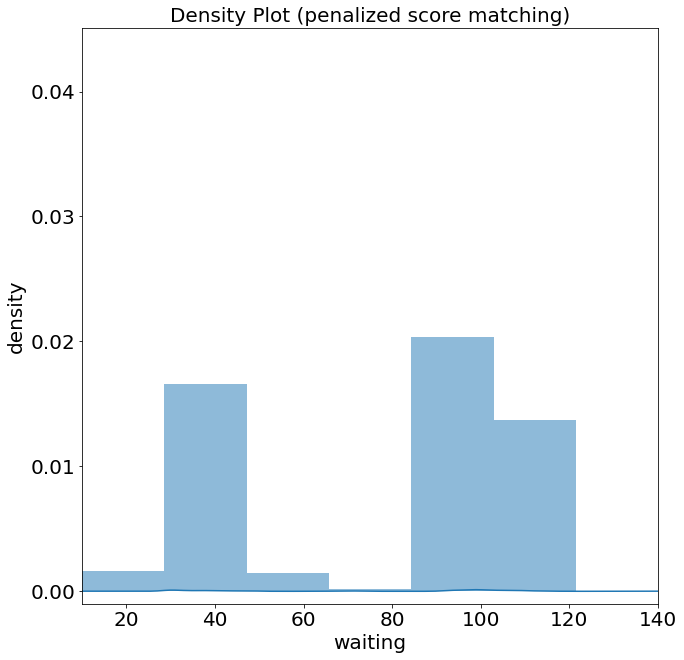

**************************************************
log penalty = -8.5


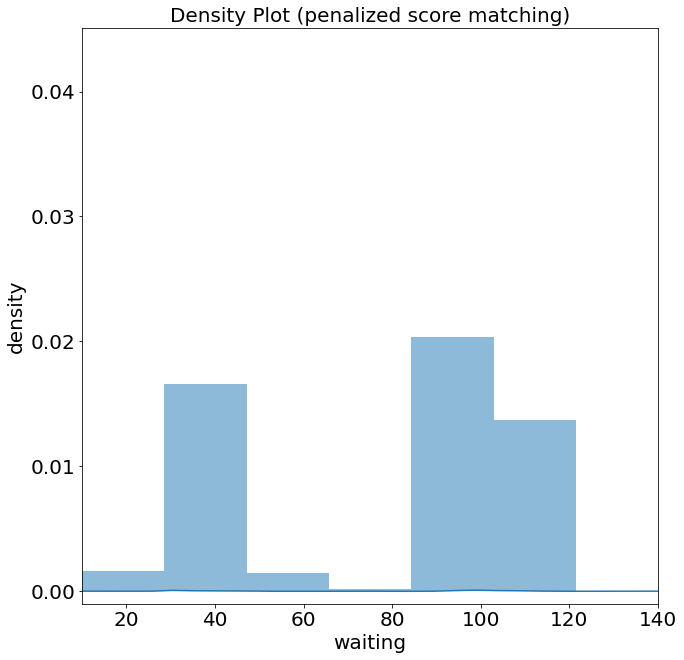

**************************************************
log penalty = -8.0


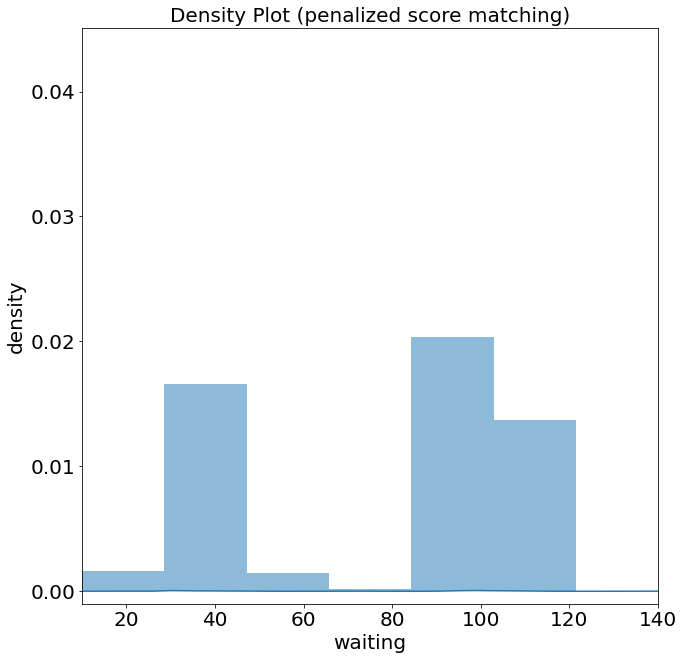

**************************************************
log penalty = -7.5


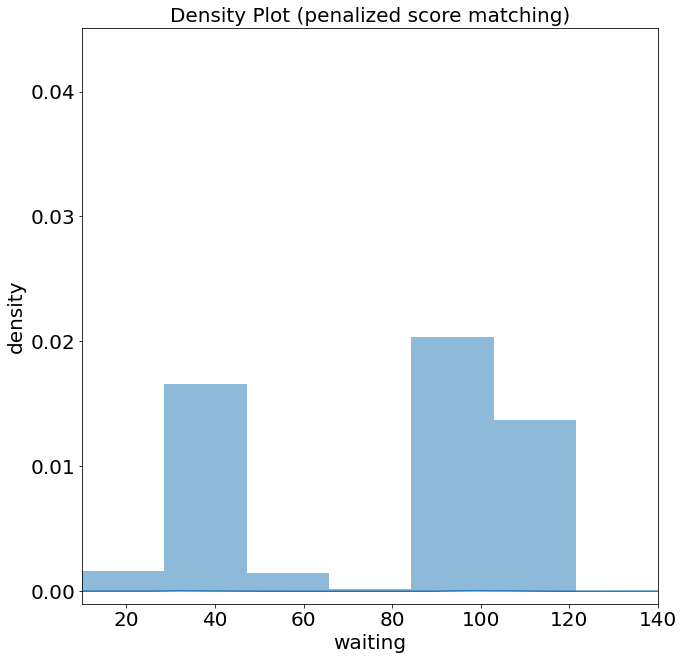

**************************************************
log penalty = -7.0


KeyboardInterrupt: 

In [9]:
log_penalty_param_list = np.arange(-12., 0., 0.5)

for log_pen_param in log_penalty_param_list: 
    
    print('*' * 50)
    print(f'log penalty = {log_pen_param}')
    
    coef_smpen = sm_pen.coef(
        data = waiting, 
        lambda_param = np.exp(log_pen_param))
    
    # visualize density estimate
    den_vals = plot_density_1d(
        data = waiting.reshape(-1, 1), 
        kernel_function = sm_pen.kernel_function_gridpoints, 
        base_density = base_density, 
        basis_type = 'grid_points', 
        coef = coef_smpen, 
        normalizing = True, 
        method = 'penalized score matching', 
        x_label = 'waiting',
        grid_points = grid_points,
        save_plot = False, 
        save_dir = None, 
        save_filename = None, 
        plot_kwargs = plot_params)
    
#     file_name_coef = f'/logpenparam={log_pen_param}-coef.npy'
#     np.save(sm_folder + file_name_coef, coef_smpen)

#     file_name_den = f'/logpenparam={log_pen_param}-densityvals-newdata.npy'
#     np.save(sm_folder + file_name_den, den_vals['den_vals'])
    